In [11]:
# Install openpyxl 
!pip install pandas openpyxl

# Load all libraties 
import numpy as np 
import seaborn as sns
import pandas as pd 

# Define the file path
file_path = "/Users/khrystynaplatko/Desktop/LakeSimcoeData_2023_refresh/SimcoeTemperatureAndDissolvedOxygen1980-2023.xlsx"

# Load the Excel file (first sheet by default)
df = pd.read_excel(file_path)

# Display the first few rows
print(df.head())


   STN SAMPLE DATE  YEAR  SAMPLE DEPTH  TEMPERATURE ⁰ C  \
0  K39  1980-04-30  1980           1.0              3.2   
1  K39  1980-04-30  1980           2.0              3.0   
2  K39  1980-04-30  1980           3.0              3.0   
3  K39  1980-04-30  1980           4.0              3.0   
4  K39  1980-04-30  1980           5.0              3.0   

   DISSOLVED OXYGEN (mg/L)  
0                     10.8  
1                     11.1  
2                     11.2  
3                     11.2  
4                     11.2  


/var/folders/ml/sgrl0zy97gdf902pd3ct59480000gn/T/ipykernel_14230/2499540723.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = data.groupby(['YEAR', 'DEPTH_BIN'])['TEMPERATURE_O_C'].mean().reset_index()


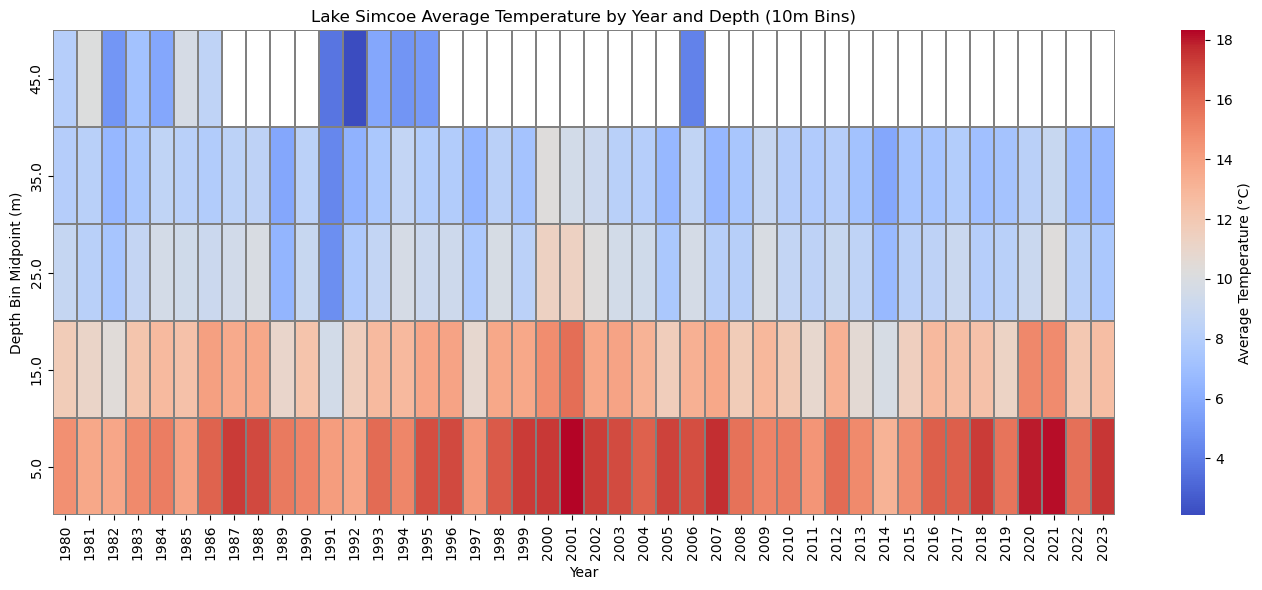

In [ ]:
# Clean column names
df.columns = df.columns.str.strip().str.upper().str.replace('⁰', 'O').str.replace(' ', '_')

# Select relevant columns and drop missing values
data = df[['YEAR', 'SAMPLE_DEPTH', 'TEMPERATURE_O_C']].dropna()

# Bin depths into 10-meter intervals
depth_bins = range(0, int(data['SAMPLE_DEPTH'].max()) + 10, 10)
data['DEPTH_BIN'] = pd.cut(data['SAMPLE_DEPTH'], bins=depth_bins, right=False)

# Calculate average temperature per (year, depth bin)
binned = data.groupby(['YEAR', 'DEPTH_BIN'])['TEMPERATURE_O_C'].mean().reset_index()

# Get the midpoint of each depth bin for plotting
binned['DEPTH_MID'] = binned['DEPTH_BIN'].apply(lambda x: (x.left + x.right) / 2)

# Format the data for heatmap format
heatmap_data = binned.pivot(index='DEPTH_MID', columns='YEAR', values='TEMPERATURE_O_C')

# Plot heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap_data.sort_index(ascending=False),  # So deeper water is lower
    cmap='coolwarm',
    cbar_kws={'label': 'Average Temperature (°C)'},
    linewidths=0.05,
    linecolor='gray'
)

plt.xlabel('Year')
plt.ylabel('Depth Bin Midpoint (m)')
plt.title('Lake Simcoe Average Temperature by Year and Depth (10m Bins)')
plt.tight_layout()
plt.show()

> What software did you use to create your data visualization?
 I used Python, specifically with the libraries pandas, seaborn.

> Who is your intended audience? 
The primary audience includes environmental researchers, government agencies, ecologists, and policy-makers interested in freshwater health, as well as community stakeholders concerned with Lake Simcoe’s long-term environmental trends.   

> What information or message are you trying to convey with your visualization? 
The visualization is designed to communicate how water temperatures have changed over time and depth in Lake Simcoe, highlighting a clear warming trend in surface waters over the past four decades. It helps viewers quickly identify thermal changes with depth and detect long-term climate impacts on lake ecology.

> What aspects of design did you consider when making your visualization? How did you apply them? With what elements of your plots? 
- Color scale: Used a ‘coolwarm’ colormap to intuitively represent cold (blue) and warm (red) temperatures.
- Depth inversion: Plotted depth with increasing values downward, matching how people conceptualize lakes.
- Grid clarity: Added light grid lines and distinct binning to avoid clutter.
- Readability: Added a title, axis labels, and a colorbar to make interpretation easier.

> How did you ensure that your data visualizations are reproducible? If the tool you used to make your data visualization is not reproducible, how will this impact your data visualization? 
- The visualization is fully reproducible through code. All processing steps, including data cleaning, binning, aggregation, and plotting, are written as a Python script. 
- This ensures that others can reproduce or modify the visualization using the same dataset.
  
> How did you ensure that your data visualization is accessible?  
- Chose a colorblind-friendly colormap that remains readable in grayscale.
- Used clear axis labels, readable font sizes, and a descriptive title.
- Ensured the heatmap does not rely solely on color, grid lines and bin placement provide spatial orientation.

   
> Who are the individuals and communities who might be impacted by your visualization?  
- Local residents and recreational users of Lake Simcoe concerned with water quality.
- Fisheries managers, as temperature shifts affect fish habitat and oxygen levels.
- Policy-makers and conservation groups advocating for climate resilience.
- Researchers studying freshwater ecology or climate change.

> How did you choose which features of your chosen dataset to include or exclude from your visualization? 
- Included variables relevant to the core message   

> What ‘underwater labour’ contributed to your final data visualization product?
- Data cleaning 
- Understanding meaning of each column 

Distinct vis can be foud in tableau here: https://public.tableau.com/app/profile/khrystyna.platko/viz/Assignment-3DSIVis/Sheet1?publish=yes 

> What software did you use to create your data visualization?
 Tableau

> Who is your intended audience? 
The primary audience includes environmental researchers, government agencies, ecologists, and policy-makers interested in freshwater health, as well as community stakeholders concerned with Lake Simcoe’s long-term environmental trends and just general public.   

> What information or message are you trying to convey with your visualization? 
The visualization aims to show changes in average temperature and sample depth over time, highlighting potential environmental trends or concerns related to lake conditions. 

> What aspects of design did you consider when making your visualization? How did you apply them? With what elements of your plots? 
- Dual-axis chart: Combines line and bar graphs to present both temperature and depth.
- Color coding: Uses different colors to distinguish between temperature and depth.
- Time series: Displays data over a timeline to show trends.


> How did you ensure that your data visualizations are reproducible? If the tool you used to make your data visualization is not reproducible, how will this impact your data visualization? 
- The raw data is availble on the web however, there the cleaned data would not be.  
- If the data for the visualization is unavailable, making it non-reproducible, it poses several challenges. Other researchers cannot verify or build upon the findings, leading to skepticism and limiting collaborative opportunities. This lack of transparency may reduce trust and credibility among stakeholders, as audiences cannot be certain of the accuracy or validity of the representation. Additionally, it restricts the ability to update or adapt the visualization with new data, diminishing its long-term usefulness and educational value. Making data accessible and transparent is crucial for enhancing the impact and reliability of any visualization.
  
> How did you ensure that your data visualization is accessible?  
- Chose a colorblind-friendly colormap that remains readable in grayscale.
- Ensuring text clarity and color contrast can make the visualization more accessible. 
- Labels and tooltips help interpret data points.
 
> Who are the individuals and communities who might be impacted by your visualization?  
- Local residents and recreational users of Lake Simcoe concerned with water quality.
- Fisheries managers, as temperature shifts affect fish habitat and oxygen levels.
- Policy-makers and conservation groups advocating for climate resilience.
- Researchers studying freshwater ecology or climate change.

> How did you choose which features of your chosen dataset to include or exclude from your visualization? 
- Chose key indicators such as temperature, depth, and dissolved oxygen at sample dates to highlight important environmental metrics.  

> What ‘underwater labour’ contributed to your final data visualization product?
- Data cleaning 
- Understanding meaning of each column 

